In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style="whitegrid")
print("Libraries loaded ✓")

Libraries loaded ✓


In [8]:
df = pd.read_csv(r"C:\Users\siphe\Downloads\bank-additional-full.csv", sep=";")
print("Shape:", df.shape)
print(df.head())

Shape: (41188, 21)
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  eur

In [9]:
print("=== Missing values ===")
print(df.isnull().sum())

print("\n=== 'unknown' counts ===")
for col in df.select_dtypes(include='object').columns:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f"  {col}: {n} ({n/len(df)*100:.1f}%)")

print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"duration == 0 rows: {(df['duration'] == 0).sum()}")
print(f"pdays == 999 (never contacted): {(df['pdays'] == 999).sum()}")

=== Missing values ===
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

=== 'unknown' counts ===
  job: 330 (0.8%)
  marital: 80 (0.2%)
  education: 1731 (4.2%)
  default: 8597 (20.9%)
  housing: 990 (2.4%)
  loan: 990 (2.4%)

Duplicate rows: 12
duration == 0 rows: 4
pdays == 999 (never contacted): 39673


In [10]:
df = df.drop_duplicates()
df = df[df['duration'] > 0]

unknown_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']
df[unknown_cols] = df[unknown_cols].replace('unknown', np.nan)

df['previously_contacted'] = (df['pdays'] != 999).astype(int)
df['pdays'] = df['pdays'].replace(999, np.nan)

df['y_binary'] = (df['y'] == 'yes').astype(int)

month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

def bucket_campaign(n):
    if n == 1: return '1 call'
    elif n == 2: return '2 calls'
    elif n == 3: return '3 calls'
    elif n <= 5: return '4-5 calls'
    elif n <= 10: return '6-10 calls'
    else: return '10+ calls'

df['campaign_bucket'] = df['campaign'].apply(bucket_campaign)
camp_order = ['1 call','2 calls','3 calls','4-5 calls','6-10 calls','10+ calls']
df['campaign_bucket'] = pd.Categorical(df['campaign_bucket'], categories=camp_order, ordered=True)

df['age_group'] = pd.cut(df['age'], bins=[0,25,35,45,55,65,100],
                         labels=['<25','25-34','35-44','45-54','55-64','65+'])

print(f"Cleaned shape: {df.shape}")

Cleaned shape: (41172, 25)


In [11]:
df.to_csv(r"C:\Users\siphe\Downloads\bank_clean.csv", index=False)
print("Saved ✓")

Saved ✓


                Stage  Count  Rate %
0        All Contacts  41172   100.0
1  Engaged (≤3 calls)  33540    81.5
2     Returning Leads   1515     3.7
3           Converted   4639    11.3


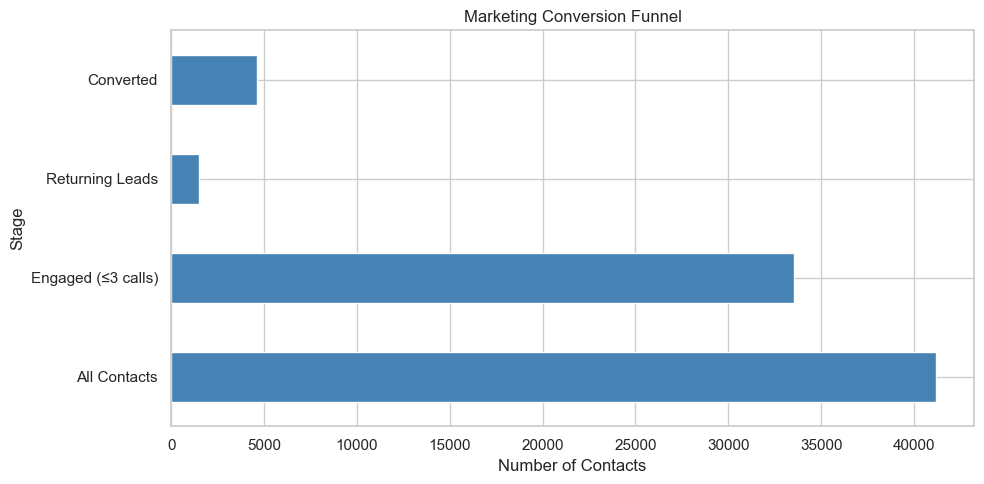

In [12]:
total = len(df)
engaged = len(df[df['campaign'] <= 3])
returning = df['previously_contacted'].sum()
converted = df['y_binary'].sum()

funnel = pd.DataFrame({
    'Stage': ['All Contacts', 'Engaged (≤3 calls)', 'Returning Leads', 'Converted'],
    'Count': [total, engaged, returning, converted],
    'Rate %': [100, engaged/total*100, returning/total*100, converted/total*100]
})
funnel['Rate %'] = funnel['Rate %'].round(1)
print(funnel)

funnel.plot(kind='barh', x='Stage', y='Count', legend=False, color='steelblue')
plt.title('Marketing Conversion Funnel')
plt.xlabel('Number of Contacts')
plt.tight_layout()
plt.show()

     Channel  Conversion Rate %
0   cellular              14.74
1  telephone               5.23


C:\Users\siphe\AppData\Local\Temp\ipykernel_26660\3839308622.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel, x='Channel', y='Conversion Rate %', palette='Blues_d')


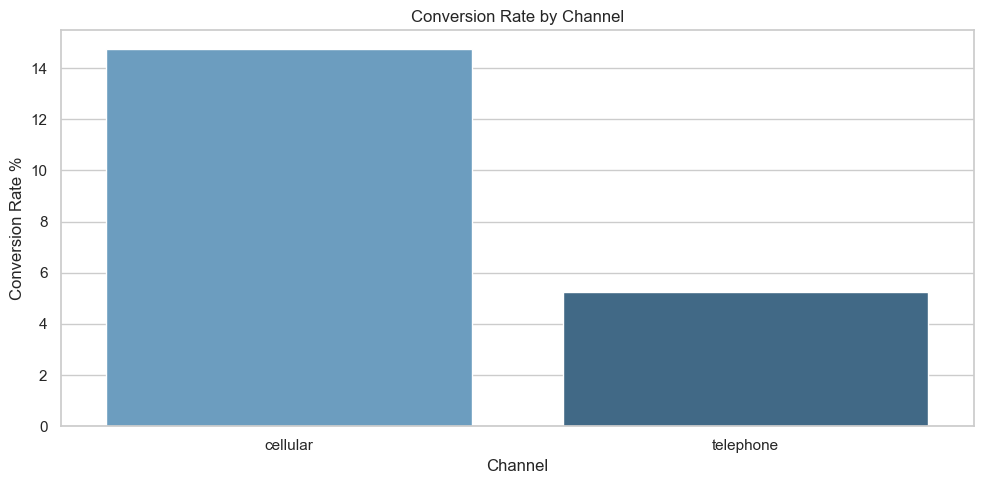

In [13]:
channel = df.groupby('contact')['y_binary'].mean().mul(100).round(2).reset_index()
channel.columns = ['Channel', 'Conversion Rate %']
print(channel)

sns.barplot(data=channel, x='Channel', y='Conversion Rate %', palette='Blues_d')
plt.title('Conversion Rate by Channel')
plt.tight_layout()
plt.show()

              Job  Conversion Rate %
0         student              31.43
1         retired              25.26
2      unemployed              14.20
3          admin.              12.97
4      management              11.22
5      technician              10.83
6   self-employed              10.49
7       housemaid              10.00
8    entrepreneur               8.52
9        services               8.14
10    blue-collar               6.90


C:\Users\siphe\AppData\Local\Temp\ipykernel_26660\3389388016.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=job, x='Conversion Rate %', y='Job', palette='viridis')


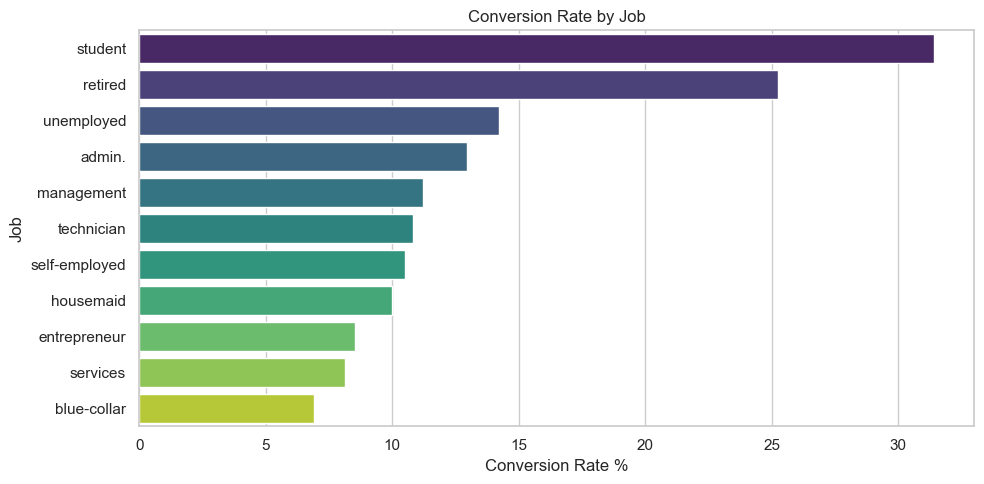

In [14]:
job = df.groupby('job')['y_binary'].mean().mul(100).round(2).sort_values(ascending=False).reset_index()
job.columns = ['Job', 'Conversion Rate %']
print(job)

sns.barplot(data=job, x='Conversion Rate %', y='Job', palette='viridis')
plt.title('Conversion Rate by Job')
plt.tight_layout()
plt.show()

              Job  Conversion Rate %
0         student              31.43
1         retired              25.26
2      unemployed              14.20
3          admin.              12.97
4      management              11.22
5      technician              10.83
6   self-employed              10.49
7       housemaid              10.00
8    entrepreneur               8.52
9        services               8.14
10    blue-collar               6.90


C:\Users\siphe\AppData\Local\Temp\ipykernel_26660\3389388016.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=job, x='Conversion Rate %', y='Job', palette='viridis')


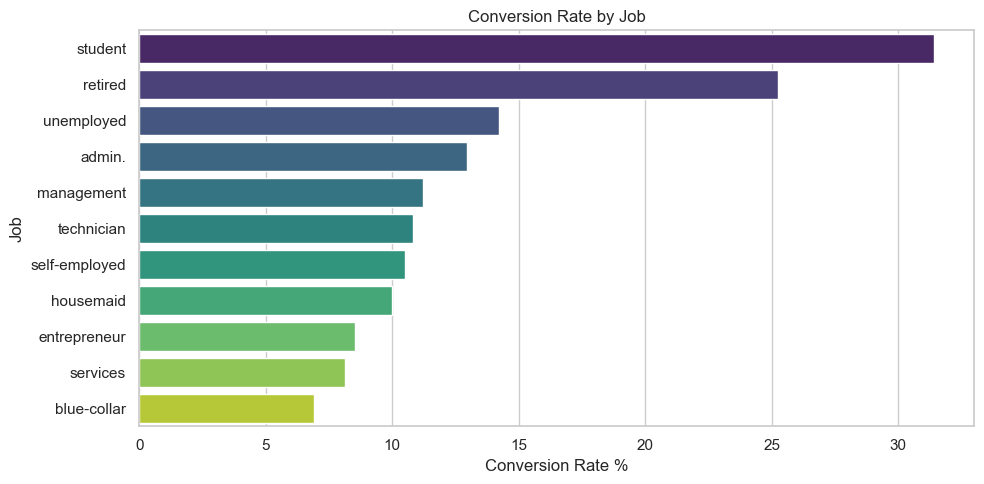

In [15]:
job = df.groupby('job')['y_binary'].mean().mul(100).round(2).sort_values(ascending=False).reset_index()
job.columns = ['Job', 'Conversion Rate %']
print(job)

sns.barplot(data=job, x='Conversion Rate %', y='Job', palette='viridis')
plt.title('Conversion Rate by Job')
plt.tight_layout()
plt.show()

  month  Total  Converted  Conversion Rate %
0   mar    546        276              50.55
1   apr   2630        539              20.49
2   may  13765        886               6.44
3   jun   5318        559              10.51
4   jul   7169        648               9.04
5   aug   6175        655              10.61
6   sep    570        256              44.91
7   oct    717        315              43.93
8   nov   4100        416              10.15
9   dec    182         89              48.90


C:\Users\siphe\AppData\Local\Temp\ipykernel_26660\4061075833.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=month, x='month', y='Conversion Rate %', palette='coolwarm')


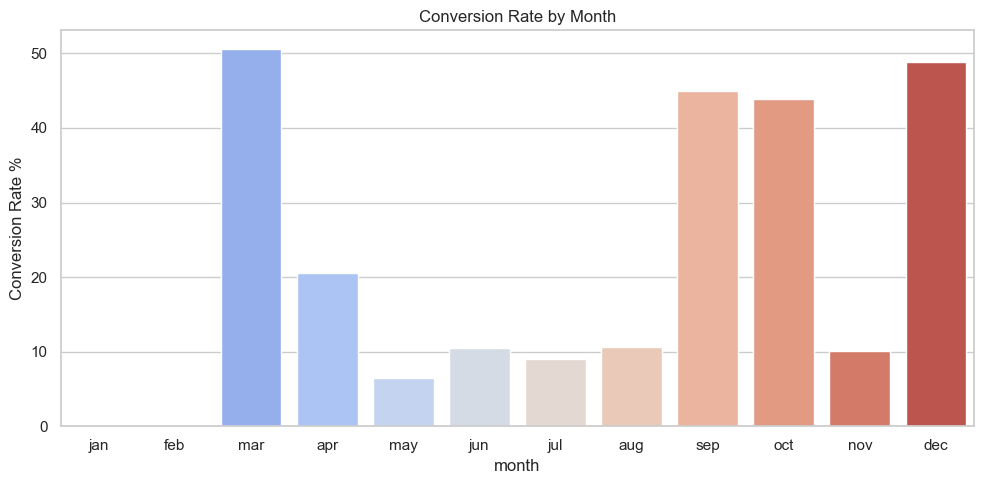

In [16]:
month = df.groupby('month', observed=True)['y_binary'].agg(Total='count', Converted='sum').reset_index()
month['Conversion Rate %'] = (month['Converted'] / month['Total'] * 100).round(2)
print(month)

sns.barplot(data=month, x='month', y='Conversion Rate %', palette='coolwarm')
plt.title('Conversion Rate by Month')
plt.tight_layout()
plt.show()

   Calls Made  Conversion Rate %
0      1 call              13.04
1     2 calls              11.46
2     3 calls              10.75
3   4-5 calls               8.69
4  6-10 calls               6.32
5   10+ calls               3.11


C:\Users\siphe\AppData\Local\Temp\ipykernel_26660\1806041857.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=camp, x='Calls Made', y='Conversion Rate %', palette='Reds_r')


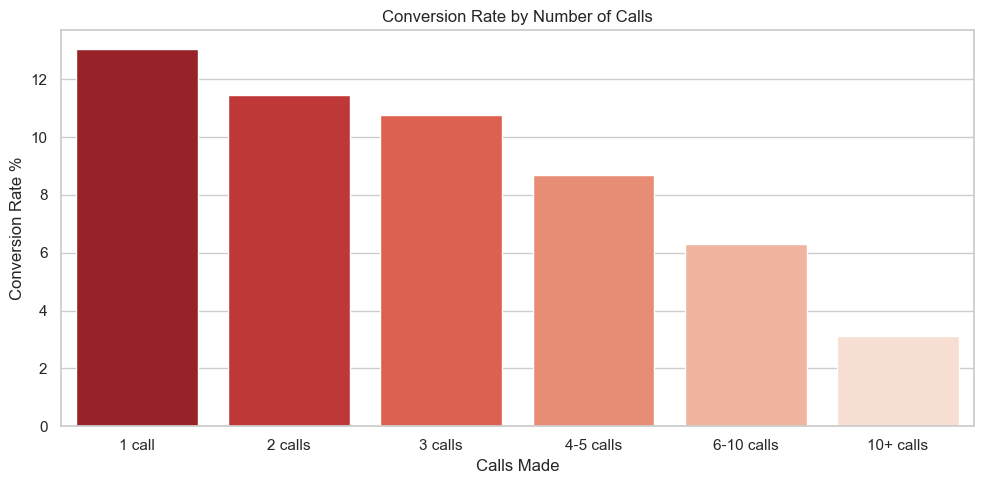

In [17]:
camp = df.groupby('campaign_bucket', observed=True)['y_binary'].mean().mul(100).round(2).reset_index()
camp.columns = ['Calls Made', 'Conversion Rate %']
print(camp)

sns.barplot(data=camp, x='Calls Made', y='Conversion Rate %', palette='Reds_r')
plt.title('Conversion Rate by Number of Calls')
plt.tight_layout()
plt.show()

  Previous Outcome  Conversion Rate %
0          failure              14.23
1      nonexistent               8.83
2          success              65.11


C:\Users\siphe\AppData\Local\Temp\ipykernel_26660\7250978.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pout, x='Previous Outcome', y='Conversion Rate %', palette='Set2')


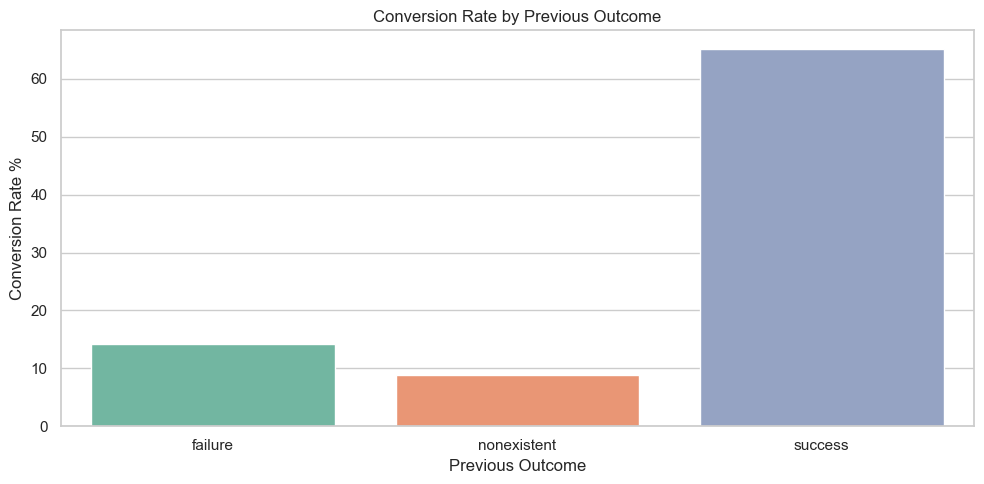

In [18]:
pout = df.groupby('poutcome')['y_binary'].mean().mul(100).round(2).reset_index()
pout.columns = ['Previous Outcome', 'Conversion Rate %']
print(pout)

sns.barplot(data=pout, x='Previous Outcome', y='Conversion Rate %', palette='Set2')
plt.title('Conversion Rate by Previous Outcome')
plt.tight_layout()
plt.show()

  Age Group  Conversion Rate %
0       <25              20.96
1     25-34              11.72
2     35-44               8.51
3     45-54               8.70
4     55-64              15.23
5       65+              46.93


C:\Users\siphe\AppData\Local\Temp\ipykernel_26660\1066696152.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age, x='Age Group', y='Conversion Rate %', palette='YlGnBu')


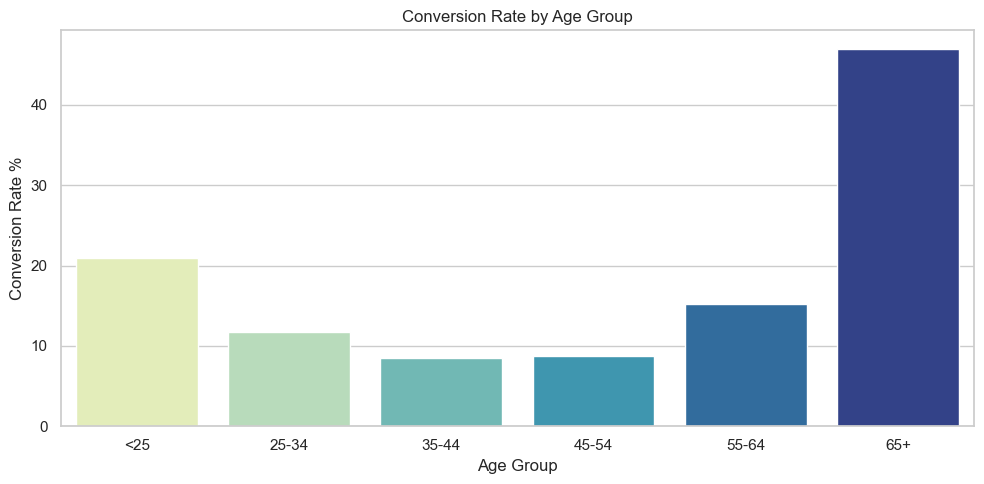

In [19]:
age = df.groupby('age_group', observed=True)['y_binary'].mean().mul(100).round(2).reset_index()
age.columns = ['Age Group', 'Conversion Rate %']
print(age)

sns.barplot(data=age, x='Age Group', y='Conversion Rate %', palette='YlGnBu')
plt.title('Conversion Rate by Age Group')
plt.tight_layout()
plt.show()

In [20]:
summary = pd.DataFrame({
    'Finding': ['Cellular vs Telephone', 'Prior successful leads', 'Best job segments', 'Best months', 'Call count drop-off'],
    'Insight': [
        'Cellular converts at 14.7% vs 5.2% telephone',
        'Prior success = 65.1% conversion — 7x baseline',
        'Students (31.4%), Retirees (25.2%) outperform average',
        'Mar/Sep/Oct/Dec convert at 44-51% vs May at 6.4%',
        'Conversion drops from 13% (1 call) to 3.1% (10+ calls)'
    ],
    'Action': [
        'Shift budget to cellular outreach',
        'Build re-engagement list before new campaigns',
        'Target students and retirees with tailored offers',
        'Run campaigns in high-rate months, reduce May volume',
        'Cap contacts at 3 calls per lead'
    ]
})
print(summary)
summary.to_csv(r"C:\Users\siphe\Downloads\recommendations.csv", index=False)
print("Saved ✓")

                  Finding                                            Insight  \
0   Cellular vs Telephone       Cellular converts at 14.7% vs 5.2% telephone   
1  Prior successful leads     Prior success = 65.1% conversion — 7x baseline   
2       Best job segments  Students (31.4%), Retirees (25.2%) outperform ...   
3             Best months   Mar/Sep/Oct/Dec convert at 44-51% vs May at 6.4%   
4     Call count drop-off  Conversion drops from 13% (1 call) to 3.1% (10...   

                                              Action  
0                  Shift budget to cellular outreach  
1      Build re-engagement list before new campaigns  
2  Target students and retirees with tailored offers  
3  Run campaigns in high-rate months, reduce May ...  
4                   Cap contacts at 3 calls per lead  
Saved ✓
